In [2]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light, pink

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.make_bal_mask import make_bal_mask
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line
from processing.get_absorption_intervals import get_absorption_intervals
from processing.parameters import CONTINUUM_WINDOWS, LYA_AIR, NV_AIR 
from utility.get_intercepts_near_line import get_intercepts_near_line

from sparcl.client import SparclClient
from dl import queryClient as qc
from astropy.table import Table
from astropy.convolution import convolve, Gaussian1DKernel
from scipy.signal import argrelmin, argrelmax
from scipy.interpolate import interp1d
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
import json
import os

relevant_erq_data_path = "data/relevant_erq_data.json"

pd.options.mode.chained_assignment = None

# fit windows
lya_window = (LYA_AIR-100,LYA_AIR+100)
nv_window = (NV_AIR-100,NV_AIR+100)


In [3]:
hamann_data = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas()
hamann_data["sdss_name"] = hamann_data["sdss_name"].astype("string")
hamann_data = hamann_data.set_index("sdss_name")
# hamann_data.info()

In [4]:
data = pd.read_json(relevant_erq_data_path)

In [5]:
def get_ci(lam,profile,interval=0.99):
    cutoff = (1-interval)/2
    
    cumsum = np.cumsum(profile)
    cumsum /= np.max(cumsum)
    
    lower_idx = np.searchsorted(cumsum,cutoff)
    upper_idx = np.searchsorted(cumsum,1-cutoff,side="left")

    return (lam[lower_idx], lam[upper_idx])

### inspection

IndexError while trying to find blue absorption boundaries


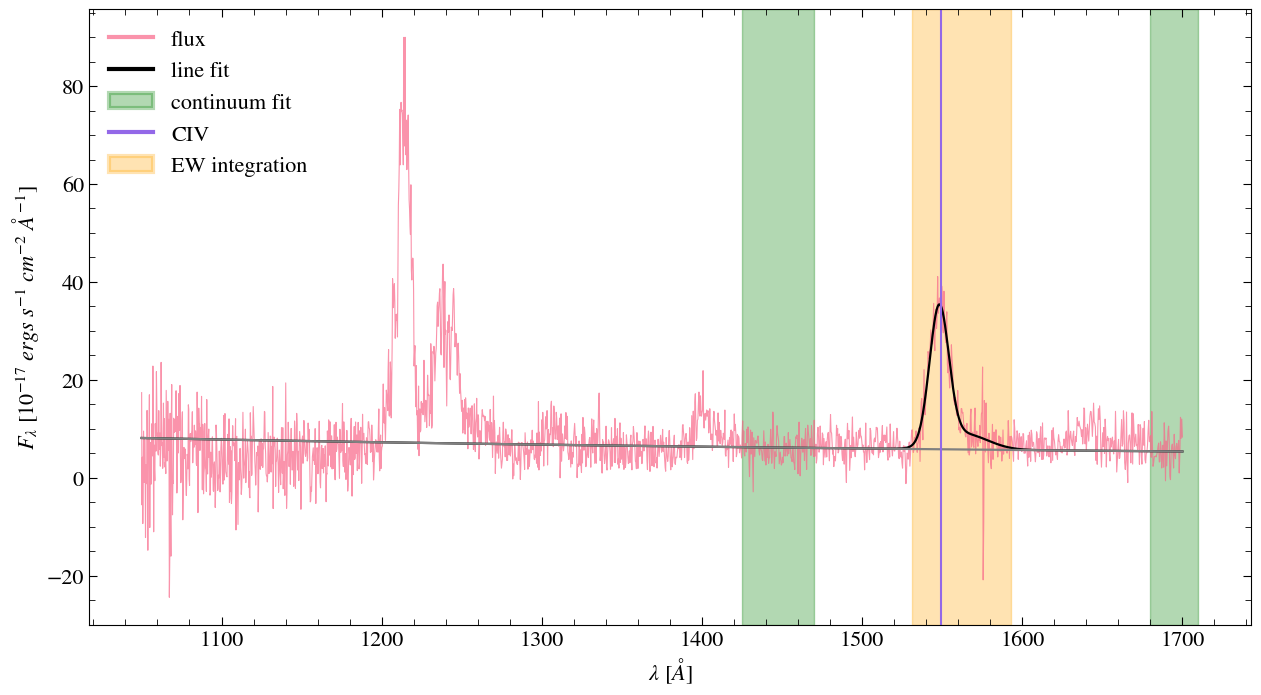


            SDSS: 014111.13-031852.5
            FWHM: 2866.855 vs 2985.648 (Hamann)
            REW: 94.573 vs 101.008 (Hamann) vs 90.971 (fit area)
            kt80: 0.35 vs 0.372 (Hamann)



In [6]:
idx = 6

## LOAD DATA

lam = np.array(data["wavelength"][idx])
flux = np.array(data["flux"][idx])
ivar = np.array(data["ivar"][idx])
z = data["redshift"][idx]

lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

# flux = convolve(flux, Gaussian1DKernel(1))


## PREPROCESSING

flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar,sigma_thresh=3)

result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result, max_slope=10)

if rejected:
    print(f'SDSS: {data["sdss_name"][idx]}\nRejected because: {reason}')
    plot_spectrum(lam, flux_clean, add_smoothed=False)


## CONTINUUM AND ABSORTION MASKING

flux_sub = flux_clean - continuum if not rejected else None

absorption_interval = get_absorption_intervals(lam,flux,ivar,continuum)

if absorption_interval is not None:
    if len(absorption_interval) == 1:
        bal_mask = (lam > absorption_interval[0][0]) & (lam < absorption_interval[0][1])
    elif len(absorption_interval) == 2:
        bal_mask = ((lam > absorption_interval[0][0]) & (lam < absorption_interval[0][1])) | ((lam > absorption_interval[1][0]) & (lam < absorption_interval[1][1]))
else:
    bal_mask = None
# bal_mask = make_bal_mask(lam, flux_sub, ivar=ivar, min_width_aa=5)


## LINE FITTING

result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=bal_mask)
result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=bal_mask, single_result=result1)

accept_two, p_val = ftest_which_gaussian(result1, result2)

if accept_two:
    # sigma_w = result2.params["sigma_w"].value
    # sigma_c = result2.params["sigma_c"].value
    # mu_w = result2.params["cen_w"].value
    # mu_c = result2.params["cen_c"].value

    # lower = min(mu_c-3*sigma_c,mu_w-3*sigma_w)
    # upper = max(mu_c+3*sigma_c,mu_w+3*sigma_w)
    # ci = (lower,upper)

    profile = profile2
else:
    # mu = result1.params["center"].value
    # sigma = result1.params["sigma"].value
    # ci = (mu-3*sigma, mu+3*sigma)
    
    profile = profile1


## LINE MEASUREMENTS AND PLOTTING

# ci = (mu-2*sigma, mu+2*sigma)
ci = get_ci(lam,profile)

plot_mask = (lam >= 1050) & (lam <= 1700)
continuum_mask = plot_mask#(lam >= 1425) & (lam <= 1810)

if absorption_interval is not None:
    line_stats, win = measure_line(lam, profile, flux_sub, continuum, ci, get_window=True)
    plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
        line_width_factor=2,
        add_smoothed=False,
        additional_lam=[lam[continuum_mask]]*2,
        additional_flux=[profile2[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
        additional_flux_label=["line fit","continuum fit"],
        line_lambda=[1549],
        line_label=["CIV"],
        shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1]), *absorption_interval],
        shaded_regions_colors=["green"]*2+["orange"]+["DodgerBlue"]*len(absorption_interval),
        shaded_regions_label=["continuum fit"]*2+["integration"]+["absorption mask"]*len(absorption_interval)
        )
else:
    line_stats, win = measure_line(lam, profile, flux_sub, continuum, ci, get_window=True)
    plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
        line_width_factor=2,
        add_smoothed=False,
        additional_lam=[lam[continuum_mask]]*2,
        additional_flux=[profile[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
        additional_flux_label=["line fit","continuum fit"],
        line_lambda=[1549],
        line_label=["CIV"],
        shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1])],
        shaded_regions_colors=["green"]*2+["orange"],
        shaded_regions_label=["continuum fit"]*2+["EW integration"]
        )

out_str = f'''
            SDSS: {data["sdss_name"][idx]}
            FWHM: {round(line_stats["fwhm_kms"],3)} vs {round(data["fwhm"][idx],3)} (Hamann)
            REW: {round(line_stats["ew_aa"],3)} vs {round(data["rew"][idx],3)} (Hamann) vs {round(line_stats["fit_rew"],3)} (fit area)
            kt80: {round(line_stats["kt80"],3)} vs {round(data["kt80"][idx],3)} (Hamann)
'''

print(out_str)

### apply what i already have

In [7]:
def get_lya_nv_masks(lam,flux,continuum):
    # get interval between lines, then the minimum, i.e. the point where the lines intersect
    interval_mask = (lam <= NV_AIR) & (lam >= LYA_AIR)
    interval_min = np.argmin(flux[interval_mask])

    local_min_lam = lam[interval_mask][interval_min]

    # get the lambdas at which LYA intersects with the continuum on the left, and NV on the right
    lower_lya, _ = get_intercepts_near_line(lam,flux,continuum,x_val=LYA_AIR)
    _, upper_nv = get_intercepts_near_line(lam,flux,continuum,x_val=NV_AIR)

    # each region is from the middle point to each their continuum intersects
    lya_region = (lower_lya,local_min_lam)
    nv_region = (local_min_lam,upper_nv)

    mask_lya = (lam >= lya_region[0]) & (lam <= lya_region[1])
    mask_nv = (lam >= nv_region[0]) & (lam <= nv_region[1])

    return mask_lya, mask_nv

#### actual fitting

In [7]:
# fit lines to continuum in respective window, masking the other region, then check which profile to plot
result1_nv, profile1_nv = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=mask_lya,window=nv_window)
result2_nv, profile2_nv = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=mask_lya, window=nv_window, single_result=result1)

accept_two_nv, p_val_nv = ftest_which_gaussian(result1_nv, result2_nv)
if accept_two_nv:
    profile_nv = profile2_nv
else:
    profile_nv = profile1_nv

result1_lya, profile1_lya = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=mask_nv,window=lya_window)
result2_lya, profile2_lya = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=mask_nv, window=lya_window, single_result=result1)

accept_two_lya, p_val_lya = ftest_which_gaussian(result1_lya, result2_lya)
if accept_two_lya:
    profile_lya = profile2_lya
else:
    profile_lya = profile1_lya

plot_spectrum(lam[plot_mask],flux[plot_mask],add_smoothed=False,additional_flux=[profile_lya[plot_mask]+continuum[plot_mask],profile_nv[plot_mask]+continuum[plot_mask],continuum[plot_mask]], additional_flux_label=[r"Ly$\alpha$","NV","continuum"],additional_flux_color=["Teal","MediumSlateBlue","black"],shaded_regions=[lya_region,nv_region],shaded_regions_label=[r"Ly$\alpha$ mask","NV mask"],shaded_regions_colors=["LightSkyBlue","Gold","YellowGreen"],line_width_factor=1.5)

NameError: name 'mask_lya' is not defined

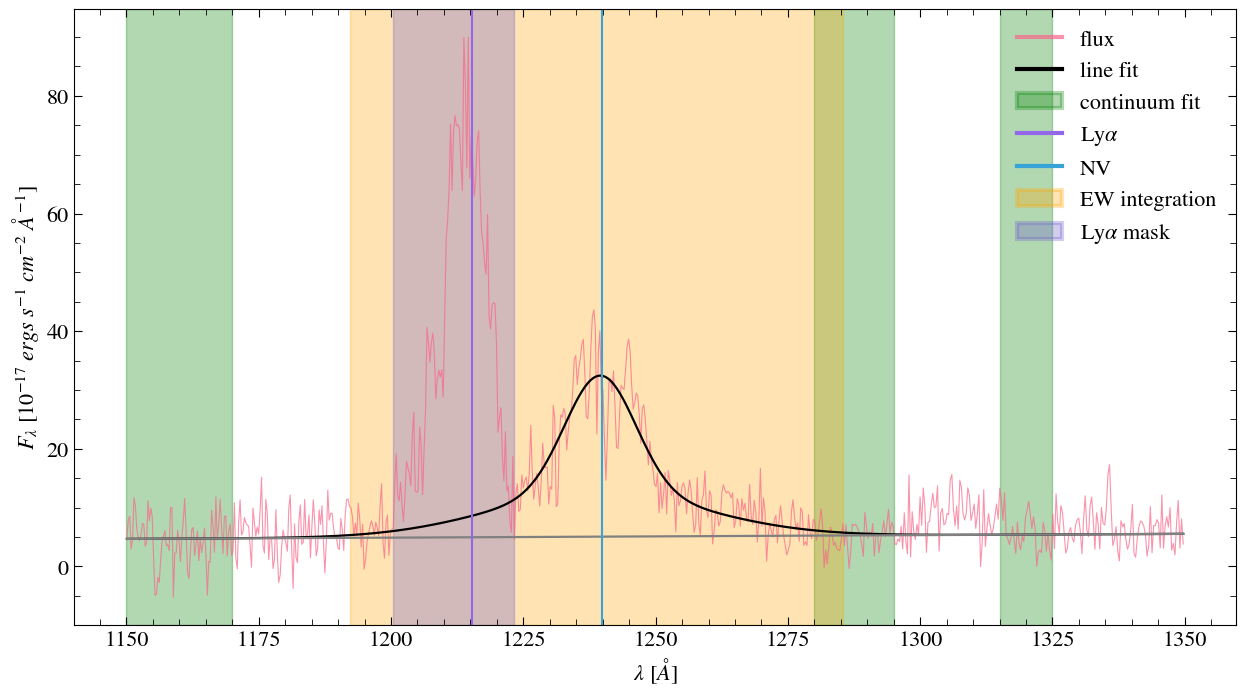


            SDSS: 014111.13-031852.5
            REW: 285.753 vs 157.85965240171538 (Hamann) vs 137.232 (fit area)



In [59]:
## LOAD DATA

idx = 6

lam = np.array(data["wavelength"][idx])
flux = np.array(data["flux"][idx])
ivar = np.array(data["ivar"][idx])
z = data["redshift"][idx]

lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)


## PREPROCESSING

flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar,sigma_thresh=3)

result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar, windows=nv_continuum_windows, lambda_ref=1290)

rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result, max_slope=10,civ_region=nv_window)

if rejected:
    print(f'SDSS: {data["sdss_name"][idx]}\nRejected because: {reason}')
    plot_spectrum(lam, flux_clean, add_smoothed=False)


## CONTINUUM AND ABSORTION MASKING

nv_continuum_windows = [
    (1150, 1170),
    (1280,1295),
    (1315,1325)
]

flux_sub = flux_clean - continuum if not rejected else None

absorption_interval = None#get_absorption_intervals(lam,flux,ivar,continuum,window=?)

if absorption_interval is not None:
    if len(absorption_interval) == 1:
        bal_mask = (lam > absorption_interval[0][0]) & (lam < absorption_interval[0][1])
    elif len(absorption_interval) == 2:
        bal_mask = ((lam > absorption_interval[0][0]) & (lam < absorption_interval[0][1])) | ((lam > absorption_interval[1][0]) & (lam < absorption_interval[1][1]))
else:
    bal_mask = None


## LINE FITTING

mask_lya, mask_nv = get_lya_nv_masks(lam,flux,continuum)

result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=mask_lya,window=nv_window)
result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=mask_lya, window=nv_window, single_result=result1)

accept_two, p_val = ftest_which_gaussian(result1, result2)

profile = profile2 if accept_two else profile1


## LINE MEASUREMENTS AND PLOTTING

ci = get_ci(lam,profile)

plot_mask = (lam >= 1150) & (lam <= 1350)
continuum_mask = plot_mask#(lam >= 1425) & (lam <= 1810)

if absorption_interval is not None:
    line_stats, win = measure_line(lam, profile, flux_sub, continuum, ci, get_window=True, window=nv_window)
    plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
        line_width_factor=2,
        add_smoothed=False,
        additional_lam=[lam[continuum_mask]]*2,
        additional_flux=[profile2[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
        additional_flux_label=["line fit","continuum fit"],
        line_lambda=[1549],
        line_label=["CIV"],
        shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1]), *absorption_interval],
        shaded_regions_colors=["green"]*2+["orange"]+["DodgerBlue"]*len(absorption_interval),
        shaded_regions_label=["continuum fit"]*2+["integration"]+["absorption mask"]*len(absorption_interval)
        )
else:
    line_stats, win = measure_line(lam, profile, flux_sub, continuum, ci, get_window=True, window=nv_window)
    plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
        line_width_factor=2,
        add_smoothed=False,
        additional_lam=[lam[continuum_mask]]*2,
        additional_flux=[profile[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
        additional_flux_label=["line fit","continuum fit"],
        line_lambda=[LYA_AIR,NV_AIR],
        line_label=[r"Ly$\alpha$","NV"],
        shaded_regions=nv_continuum_windows+[(lam[win][0], lam[win][-1]),lya_region],
        shaded_regions_colors=["green"]*3+["orange","slateblue"],
        shaded_regions_label=["continuum fit"]*3+["EW integration",r"Ly$\alpha$ mask"]
        )

name = data["sdss_name"][idx]

out_str = f'''
            SDSS: {name}
            REW: {round(line_stats["ew_aa"],3)} vs {hamann_data.loc[name,"rew_nv"]} (Hamann) vs {round(line_stats["fit_rew"],3)} (fit area)
'''

print(out_str)

### new

In [8]:
## LOAD DATA

idx = 6

lam = np.array(data["wavelength"][idx])
flux = np.array(data["flux"][idx])
ivar = np.array(data["ivar"][idx])
z = data["redshift"][idx]

lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)


## PREPROCESSING & CONTINUUM

nv_continuum_windows = [
    (1150, 1170),
    (1280,1295),
    (1315,1325)
]

flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar,sigma_thresh=3)

result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar, windows=nv_continuum_windows, lambda_ref=1290)

rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result, max_slope=10,civ_region=nv_window)

if rejected:
    print(f'SDSS: {data["sdss_name"][idx]}\nRejected because: {reason}')
    plot_spectrum(lam, flux_clean, add_smoothed=False)


## ABSORTION MASKING

flux_sub = flux_clean - continuum if not rejected else None

absorption_interval = None#get_absorption_intervals(lam,flux,ivar,continuum,window=?)

if absorption_interval is not None:
    if len(absorption_interval) == 1:
        bal_mask = (lam > absorption_interval[0][0]) & (lam < absorption_interval[0][1])
    elif len(absorption_interval) == 2:
        bal_mask = ((lam > absorption_interval[0][0]) & (lam < absorption_interval[0][1])) | ((lam > absorption_interval[1][0]) & (lam < absorption_interval[1][1]))
else:
    bal_mask = None

In [9]:
from processing.fit_gaussians import _gaussian
from lmfit import Model, Parameters

In [ ]:
LYA_NV_FIT_WINDOW = (1150,1290)  # from Shen2019


def _lya_nv_gaussians():
    lya_core = _gaussian(x, lya_amp_c, lya_cen_c)
    lya_wing = _gaussian(x, lya_amp_w, lya_cen_w, lya_sigma_w)
    nv_core = _gaussian(x, nv_amp_c, nv_cen_c, nv_sigma_c)
    nv_wing = _gaussian(x, nv_amp_w, nv_cen_w, nv_sigma_w)
    return lya_core + lya_wing + nv_core + nv_wing


def fit_lya_nv(lam, flux_sub, ivar=None, mask=None, window=LYA_NV_FIT_WINDOW):
    win = (lam >= window[0]) & (lam <= window[1])
    if mask is not None:
        win &= ~mask
    if win.sum() < 8:
        raise ValueError("Too few pixels for fit.")

    xd = lam[win]
    yd = flux_sub[win]
    weights = np.sqrt(ivar[win]) if ivar is not None else np.ones(win.sum())
    weights = np.where(np.isfinite(weights) & (weights > 0), weights, 1.0)


    # find initial guesses
    center_mask = (lam > LYA_AIR) & (lam < NV_AIR)
    center_min_idx = np.argmin(flux_sub[center_mask])
    center_lam = lam[center_mask][center_min_idx]

    lya_max = np.max(flux_sub[(lam < center_lam)])
    nv_max = np.max(flux_sub[(lam > center_lam)])


    model = Model(_lya_nv_gaussians)
    params = Parameters()

    # TODO add params

    ## PLOTTING
    lya_argmax = np.argmax(flux_sub[(lam < center_lam)])
    nv_argmax = np.argmax(flux_sub[(lam > center_lam)])

    plot_mask = (lam >= 1100) & (lam <= 1340)
    plot_spectrum(lam[plot_mask],flux_sub[plot_mask],add_smoothed=False,line_lambda=[lam[(lam > LYA_NV_FIT_WINDOW[0]) & (lam < center_lam)][lya_argmax],lam[(lam > center_lam) & (lam < LYA_NV_FIT_WINDOW[1])][nv_argmax],center_lam],line_width_factor=2)
    print(lya_max,nv_max)

fit_lya_nv(lam, flux_sub, ivar=ivar, mask=bal_mask)


IndexError: pop from empty list